<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 157.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 152.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 125.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 139.0 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


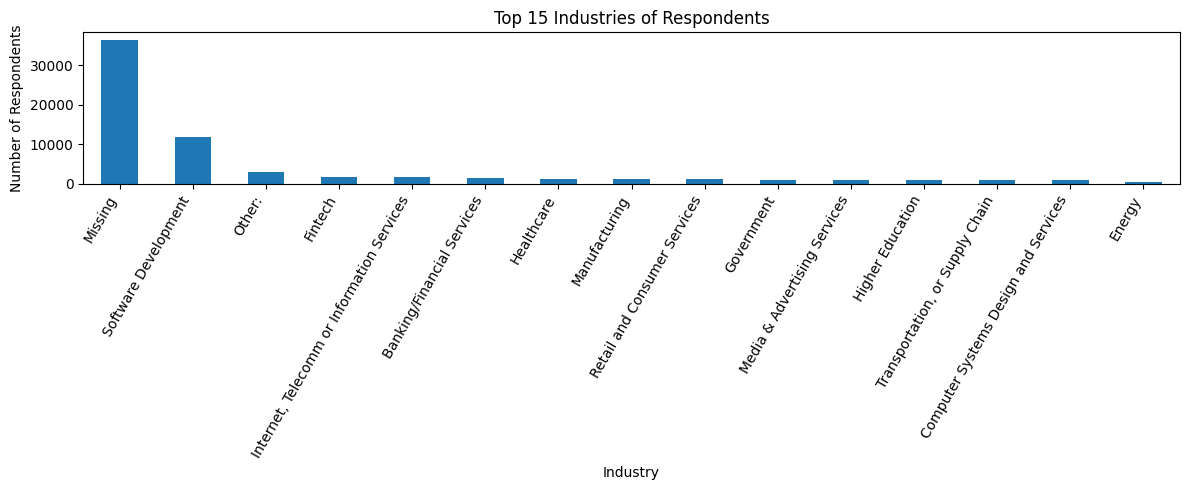

Industry
Missing                                       36579
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Higher Education                                890
Transportation, or Supply Chain                 859
Computer Systems Design and Services            844
Energy                                          578
Name: count, dtype: int64

In [4]:
##Write your code here
# Distribution of respondents by Industry
industry_counts = df["Industry"].fillna("Missing").value_counts()

plt.figure(figsize=(12, 5))
industry_counts.head(15).plot(kind="bar")
plt.title("Top 15 Industries of Respondents")
plt.xlabel("Industry")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Optional: show the counts table
industry_counts.head(15)

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [5]:
##Write your code here
# Ensure ConvertedCompYearly is numeric
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")

comp = df["ConvertedCompYearly"].dropna()

mean_comp = comp.mean()
median_comp = comp.median()
std_comp = comp.std()

print("Mean:", mean_comp)
print("Median:", median_comp)
print("Std Dev:", std_comp)

threshold = mean_comp + 3 * std_comp
print("Outlier threshold (mean + 3*std):", threshold)

extreme_outliers = df[df["ConvertedCompYearly"] > threshold][["ConvertedCompYearly", "Country", "Employment"]]
print("Number of extreme outliers:", extreme_outliers.shape[0])

extreme_outliers.sort_values("ConvertedCompYearly", ascending=False).head(10)

Mean: 86155.28726264134
Median: 65000.0
Std Dev: 186756.97308629754
Outlier threshold (mean + 3*std): 646426.206521534
Number of extreme outliers: 89


,ConvertedCompYearly,Country,Employment
15837,16256603.0,Ethiopia,"Independent contractor, freelancer, or self-em..."
12723,13818022.0,South Africa,"Employed, full-time;Independent contractor, fr..."
28379,9000000.0,Taiwan,"Employed, full-time"
17593,6340564.0,Brazil,"Employed, full-time"
17672,4936778.0,Ukraine,"Employed, full-time"
19267,3367716.0,India,"Employed, full-time"
23694,2584118.0,Pakistan,"Employed, full-time;Independent contractor, fr..."
33720,2237846.0,Brazil,"Independent contractor, freelancer, or self-em..."
34523,2153432.0,Pakistan,"Employed, full-time"
13763,2048046.0,Australia,"Employed, full-time"


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1: 32712.0
Q3: 107971.5
IQR: 75259.5
Lower bound: -80177.25
Upper bound: 220860.75
Number of IQR outliers: 978


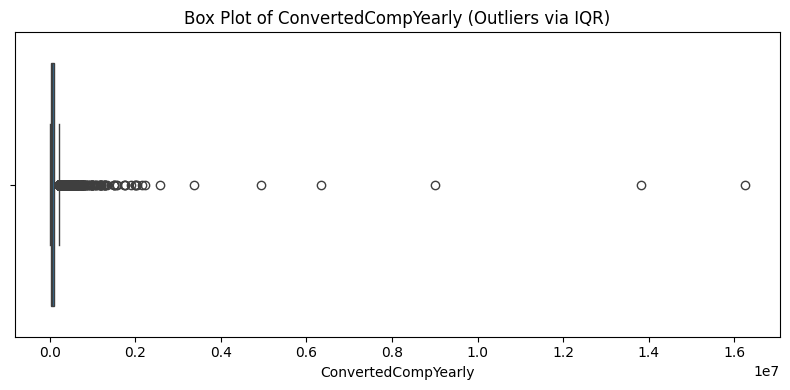

In [6]:
##Write your code here
comp = df["ConvertedCompYearly"].dropna()

Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

iqr_outliers_mask = (df["ConvertedCompYearly"] < lower_bound) | (df["ConvertedCompYearly"] > upper_bound)
print("Number of IQR outliers:", iqr_outliers_mask.sum())

plt.figure(figsize=(8, 4))
sns.boxplot(x=df["ConvertedCompYearly"])
plt.title("Box Plot of ConvertedCompYearly (Outliers via IQR)")
plt.xlabel("ConvertedCompYearly")
plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [7]:
##Write your code here
df_no_outliers = df[~iqr_outliers_mask].copy()

print("Original shape:", df.shape)
print("After removing IQR outliers:", df_no_outliers.shape)
print("Removed rows:", df.shape[0] - df_no_outliers.shape[0])

Original shape: (65437, 114)
After removing IQR outliers: (64459, 114)
Removed rows: 978


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat,Age_num
ResponseId,1.000000,-0.000000,0.019678,-0.002078,-0.016506,-0.016500,-0.002940,-0.000551,-0.004597,0.000632,-0.008033,-0.007793,-0.012948,0.003572,-0.031809
CompTotal,-0.000000,0.000000,0.029528,-0.004937,-0.002756,-0.003093,-0.006402,-0.006000,-0.004653,-0.004566,-0.003262,-0.003098,0.030847,-0.015995,-0.002732
WorkExp,0.019678,0.029528,1.000000,-0.028027,-0.066619,-0.103401,-0.064461,-0.099224,-0.046430,-0.086464,-0.111326,-0.107360,0.408438,0.095345,0.849536
JobSatPoints_1,-0.002078,-0.004937,-0.028027,1.000000,0.448552,0.636337,0.622532,0.607344,0.632247,0.601971,0.588641,0.610619,-0.058170,0.093561,-0.029161
JobSatPoints_4,-0.016506,-0.002756,-0.066619,0.448552,1.000000,0.527358,0.451213,0.460239,0.441809,0.474636,0.500610,0.528388,-0.095050,0.029477,-0.075195
JobSatPoints_5,-0.016500,-0.003093,-0.103401,0.636337,0.527358,1.000000,0.615095,0.608357,0.631581,0.620540,0.643527,0.691287,-0.185850,0.049731,-0.100555
JobSatPoints_6,-0.002940,-0.006402,-0.064461,0.622532,0.451213,0.615095,1.000000,0.693467,0.648146,0.633407,0.593731,0.605489,-0.090162,0.052816,-0.049536
JobSatPoints_7,-0.000551,-0.006000,-0.099224,0.607344,0.460239,0.608357,0.693467,1.000000,0.701129,0.660599,0.643777,0.618532,-0.159449,0.040047,-0.080870
JobSatPoints_8,-0.004597,-0.004653,-0.046430,0.632247,0.441809,0.631581,0.648146,0.701129,1.000000,0.658592,0.619533,0.627418,-0.100068,0.058825,-0.045954
JobSatPoints_9,0.000632,-0.004566,-0.086464,0.601971,0.474636,0.620540,0.633407,0.660599,0.658592,1.000000,0.663536,0.651760,-0.125813,0.040530,-0.080421


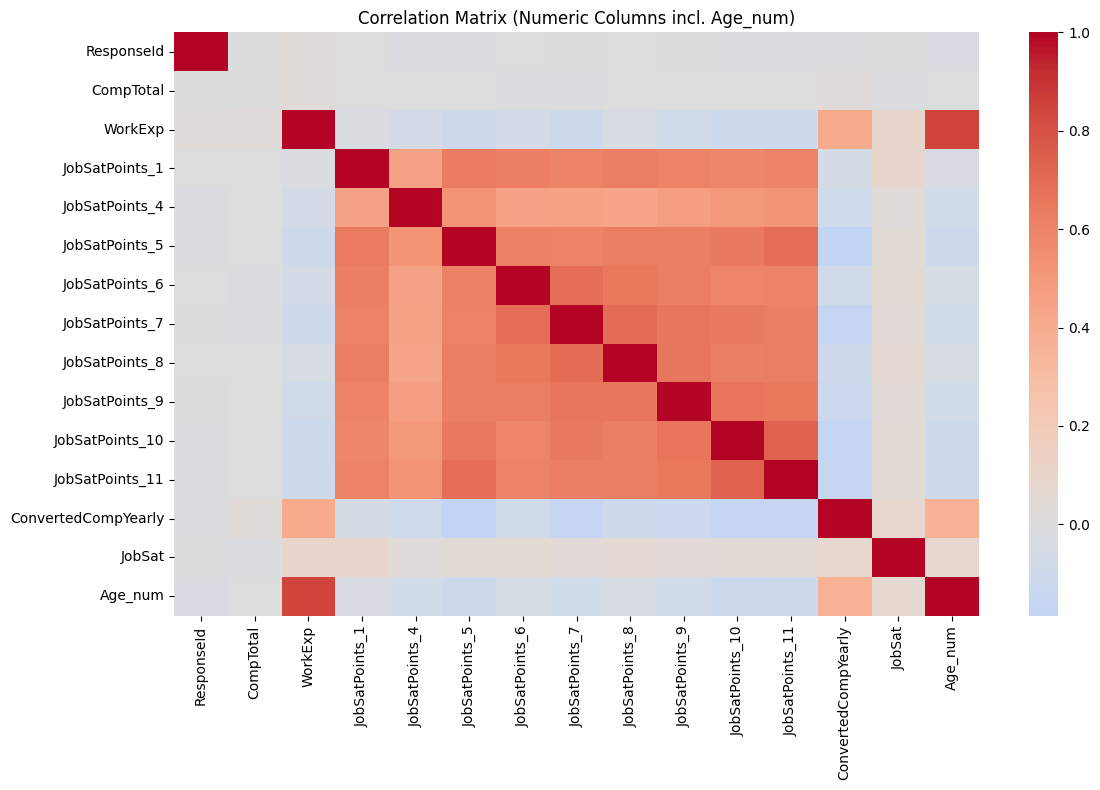

In [8]:
##Write your code here
# Convert Age groups into approximate numeric values
age_s = df_no_outliers["Age"].astype("string").str.replace("–", "-", regex=False)

# Extract ranges like 18-24
age_ranges = age_s.str.extract(r'(\d+)\s*-\s*(\d+)').apply(pd.to_numeric, errors="coerce")
age_numeric = age_ranges.mean(axis=1)

# Handle special groups if present
age_numeric = age_numeric.where(~age_s.str.contains("Under 18", na=False), 17)
age_numeric = age_numeric.where(~age_s.str.contains("65 years or older", na=False), 70)

df_no_outliers["Age_num"] = age_numeric

# Select numeric columns and compute correlation
numeric_df = df_no_outliers.select_dtypes(include="number").copy()

corr = numeric_df.corr()
display(corr)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Columns incl. Age_num)")
plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
